In [1]:
!pip install xgboost statsmodels tensorflow scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

from statsmodels.tsa.arima.model import ARIMA

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

In [3]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\Hydropower_final_model_ready.csv")

print(df.head())
print(df.columns)

         Date     Open     High      Low    Close        Volume     Turn Over  \
0  2021-09-12  3398.45  3580.13  3398.39  3571.49  4.197007e+09  1.498957e+13   
1  2021-09-13  3615.15  3646.27  3454.92  3480.58  3.697186e+09  1.286835e+13   
2  2021-09-14  3484.71  3511.67  3416.22  3449.76  1.788999e+09  6.171619e+12   
3  2021-09-15  3444.52  3455.94  3351.45  3376.77  1.707492e+09  5.765808e+12   
4  2021-09-16  3375.02  3375.03  3197.24  3238.98  2.738892e+09  8.871215e+12   

   Log_Return  Return_5D  Return_10D  ...  Volume_Ratio_20D  Volume_Spike  \
0    0.062710   0.147187   -0.030232  ...          0.949996         False   
1   -0.025784   0.024676   -0.031121  ...          0.861178         False   
2   -0.008894   0.031238   -0.005291  ...          0.435198         False   
3   -0.021385   0.025775   -0.020405  ...          0.438728         False   
4   -0.041661  -0.034409   -0.027430  ...          0.722716         False   

   Cumulative_Return  Running_Max_Close  Drawdown 

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

In [5]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Now remove the original Date column
df = df.drop(columns=['Date'])

In [6]:
X = df.drop(columns=[
    'Target_Next_1D_Return',
    'Target_Next_1D_Direction'
])

y = df['Target_Next_1D_Return']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False,
    random_state=42
)

# XGBOOST

In [8]:
xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [9]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [10]:
pred = xgb.predict(X_test)

In [11]:
xgb_rmse = np.sqrt(mean_squared_error(y_test, pred))
xgb_mae = mean_absolute_error(y_test, pred)
xgb_r2 = r2_score(y_test, pred)

print("========== XGBoost Results ==========")
print("RMSE :", xgb_rmse)
print("MAE  :", xgb_mae)
print("R²   :", xgb_r2)

========== XGBoost Results ==========
RMSE : 0.014999182243271191
MAE  : 0.011181736205545115
R²   : -0.3089612672337656


# Actual vs Predicted Plot

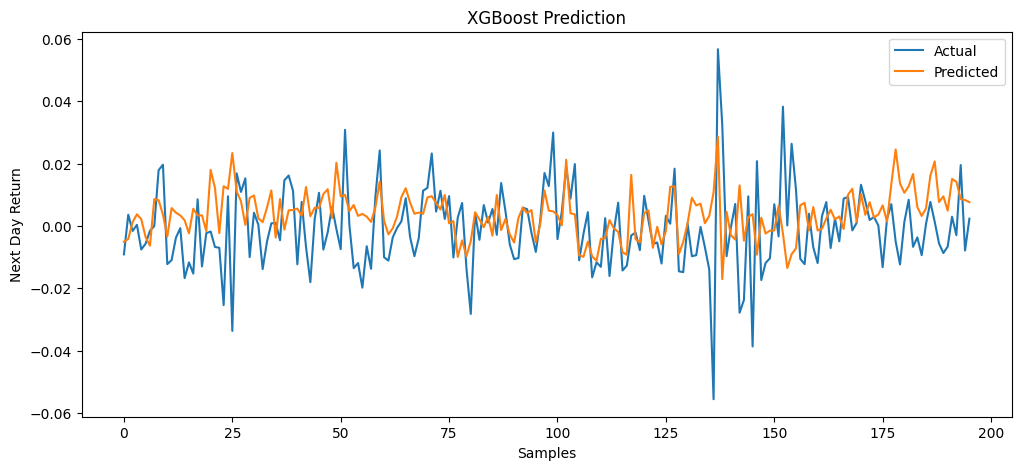

In [12]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values, label="Actual")
plt.plot(pred, label="Predicted")

plt.title("XGBoost Prediction")

plt.xlabel("Samples")

plt.ylabel("Next Day Return")

plt.legend()

plt.show()

# Residual PLot

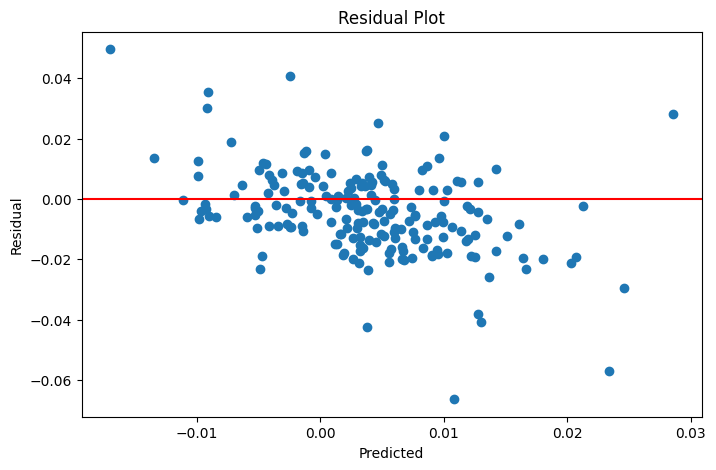

In [13]:
residuals = y_test - pred

plt.figure(figsize=(8,5))

plt.scatter(pred, residuals)

plt.axhline(0, color='red')

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# ARIMA

In [14]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\Hydropower_final_model_ready.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

series = df['Target_Next_1D_Return']

In [16]:
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

In [17]:
model = ARIMA(train, order=(1,0,1))

model_fit = model.fit()

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting au

In [18]:
forecast = model_fit.forecast(steps=len(test))

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [19]:
print(forecast.head())
print(test.head())

781   -0.000029
782    0.000006
783    0.000007
784    0.000007
785    0.000007
Name: predicted_mean, dtype: float64
Date
2025-02-12   -0.009118
2025-02-13    0.003614
2025-02-16   -0.001594
2025-02-17    0.000368
2025-02-18   -0.007543
Name: Target_Next_1D_Return, dtype: float64


In [20]:
arima_rmse = np.sqrt(mean_squared_error(test, forecast))
arima_mae = mean_absolute_error(test, forecast)
arima_r2 = r2_score(test, forecast)

print("========== ARIMA Results ==========")
print("RMSE :", arima_rmse)
print("MAE  :", arima_mae)
print("R²   :", arima_r2)

========== ARIMA Results ==========
RMSE : 0.013133153021685946
MAE  : 0.009690442587837007
R²   : -0.0035283383429929316


In [21]:
print(series.head())
print(series.describe())

Date
2021-09-12   -0.025784
2021-09-13   -0.008894
2021-09-14   -0.021385
2021-09-15   -0.041661
2021-09-16   -0.070595
Name: Target_Next_1D_Return, dtype: float64
count    977.000000
mean      -0.000145
std        0.019695
min       -0.070595
25%       -0.011668
50%       -0.002094
75%        0.009310
max        0.082805
Name: Target_Next_1D_Return, dtype: float64


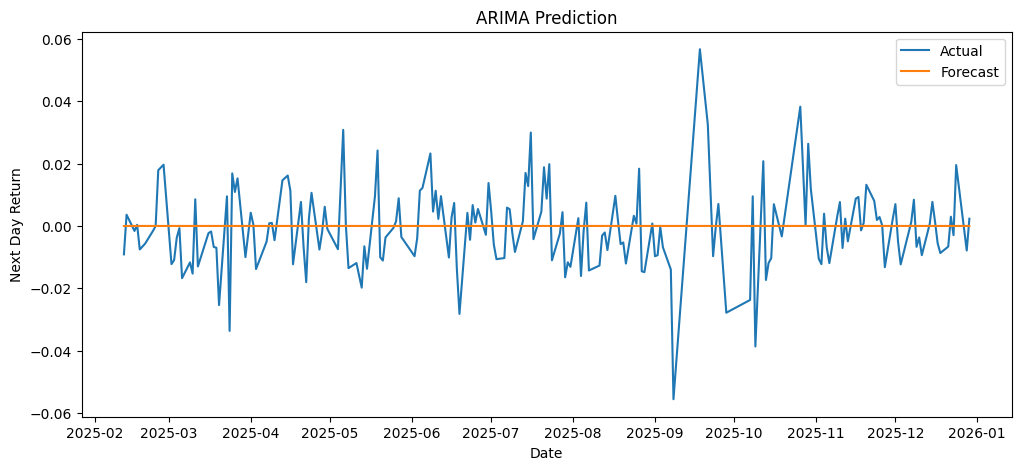

In [22]:
plt.figure(figsize=(12,5))

plt.plot(test.index,test.values,label="Actual")

plt.plot(test.index,forecast,label="Forecast")

plt.title("ARIMA Prediction")

plt.xlabel("Date")

plt.ylabel("Next Day Return")

plt.legend()

plt.show()

# LSTM

In [23]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\Hydropower_final_model_ready.csv")
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

In [25]:
X = df.drop(columns=[
    'Date',
    'Target_Next_1D_Return',
    'Target_Next_1D_Direction'
])

y = df['Target_Next_1D_Return']

In [26]:
feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()

X_scaled = feature_scaler.fit_transform(X)

y_scaled = target_scaler.fit_transform(
    y.values.reshape(-1,1)
)

# 7-Day Sequences

In [27]:
time_step = 7

X_seq = []

y_seq = []

for i in range(len(X_scaled)-time_step):

    X_seq.append(X_scaled[i:i+time_step])

    y_seq.append(y_scaled[i+time_step])

X_seq = np.array(X_seq)

y_seq = np.array(y_seq)

In [28]:
split = int(len(X_seq)*0.8)

X_train = X_seq[:split]

X_test = X_seq[split:]

y_train = y_seq[:split]

y_test = y_seq[split:]

In [29]:
model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(7,X_train.shape[2])
    )
)

model.add(Dropout(0.2))

model.add(LSTM(32))

model.add(Dropout(0.2))

model.add(Dense(16,activation='relu'))

model.add(Dense(1))

model.compile(

    optimizer='adam',

    loss='mse'
)

model.summary()

C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 7, 64)               │          26,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 7, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 39,073 (152.63 KB)

 Trainable params: 39,073 (152.63 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = model.fit(

    X_train,

    y_train,

    epochs=50,

    batch_size=32,

    validation_data=(X_test,y_test),

    verbose=1
)

Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0577 - val_loss: 0.0116
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0234 - val_loss: 0.0147
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0227 - val_loss: 0.0114
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0205 - val_loss: 0.0084
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0215 - val_loss: 0.0091
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0200 - val_loss: 0.0100
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0204 - val_loss: 0.0075
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0204 - val_loss: 0.0078
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0210 - val_loss: 0.0079
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0209 - val_loss: 0.0086
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0199 - val_loss: 0.0077
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

In [31]:
pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step 


In [32]:
pred = target_scaler.inverse_transform(pred)

actual = target_scaler.inverse_transform(y_test)

In [33]:
lstm_rmse = np.sqrt(mean_squared_error(actual, pred))
lstm_mae = mean_absolute_error(actual, pred)
lstm_r2 = r2_score(actual, pred)

print("========== LSTM Results ==========")
print("RMSE :", lstm_rmse)
print("MAE  :", lstm_mae)
print("R²   :", lstm_r2)

========== LSTM Results ==========
RMSE : 0.013367428765465338
MAE  : 0.009939866826212987
R²   : -0.03176636632273855


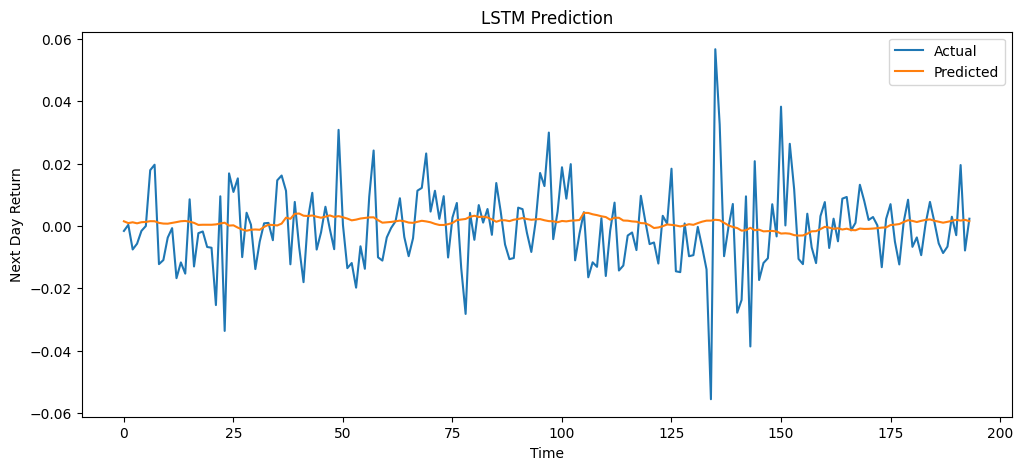

In [34]:
plt.figure(figsize=(12,5))

plt.plot(actual,label="Actual")

plt.plot(pred,label="Predicted")

plt.title("LSTM Prediction")

plt.xlabel("Time")

plt.ylabel("Next Day Return")

plt.legend()

plt.show()

# Comparison Table

In [35]:
results = pd.DataFrame({
    "Model": ["XGBoost", "ARIMA", "LSTM"],
    "RMSE": [xgb_rmse, arima_rmse, lstm_rmse],
    "MAE": [xgb_mae, arima_mae, lstm_mae],
    "R2": [xgb_r2, arima_r2, lstm_r2]
})

print(results)

     Model      RMSE       MAE        R2
0  XGBoost  0.014999  0.011182 -0.308961
1    ARIMA  0.013133  0.009690 -0.003528
2     LSTM  0.013367  0.009940 -0.031766


# Best Model

In [36]:
best = results.loc[results['RMSE'].idxmin()]

print("Best Model:")
print(best)

Best Model:
Model       ARIMA
RMSE     0.013133
MAE       0.00969
R2      -0.003528
Name: 1, dtype: object


In [37]:
print("XGBoost")
print(xgb_rmse, xgb_mae, xgb_r2)

print("\nARIMA")
print(arima_rmse, arima_mae, arima_r2)

print("\nLSTM")
print(lstm_rmse, lstm_mae, lstm_r2)

XGBoost
0.014999182243271191 0.011181736205545115 -0.3089612672337656

ARIMA
0.013133153021685946 0.009690442587837007 -0.0035283383429929316

LSTM
0.013367428765465338 0.009939866826212987 -0.03176636632273855


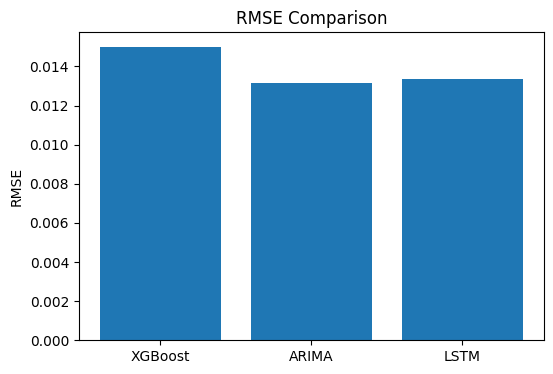

In [38]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

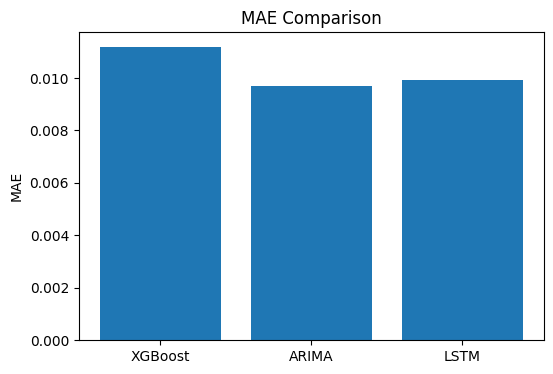

In [39]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["MAE"])
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.show()

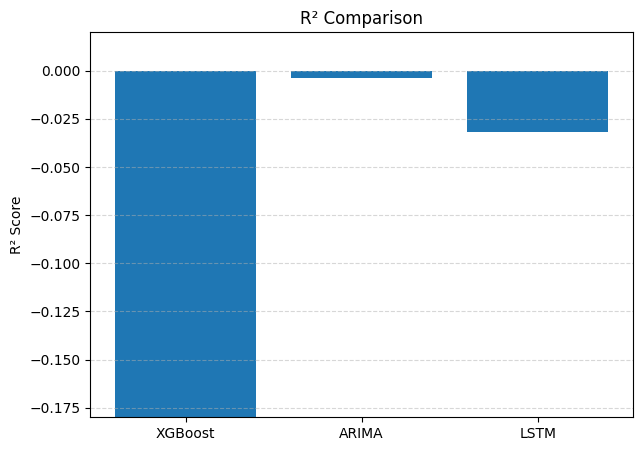

In [40]:
plt.figure(figsize=(7,5))

plt.bar(results["Model"], results["R2"])

plt.title("R² Comparison")
plt.ylabel("R² Score")

plt.ylim(-0.18, 0.02)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [41]:
print(results.round(4))

     Model    RMSE     MAE      R2
0  XGBoost  0.0150  0.0112 -0.3090
1    ARIMA  0.0131  0.0097 -0.0035
2     LSTM  0.0134  0.0099 -0.0318
